# CLAM 原理·玩具版：30 行代码亲手训一个"会找肿瘤"的模型

> 这个 notebook 只回答一个问题：**MIL + 注意力到底是怎么"没人教就学会找肿瘤"的？**
>
> 方法：不用真实病理数据（太慢太复杂），我们自己**造**一批假切片——假到每个 patch 只有 4 个数字。
> 因为标准答案在我们手里，所以能亲眼检查模型找得对不对。
>
> 全部代码在 CPU 上一两分钟跑完。读完这个，再回头看主 notebook §5 打印出来的 CLAM_SB 结构，保证全都对上号。
>
> 📚 **玩具版系列**：本篇讲 CLAM（弱监督分类）；姊妹篇 [UNI2_原理_玩具版.ipynb](UNI2_原理_玩具版.ipynb)（无标签学特征）、[CONCH_原理_玩具版.ipynb](CONCH_原理_玩具版.ipynb)（图文对齐）、[TITAN_原理_玩具版.ipynb](TITAN_原理_玩具版.ipynb)（切片级基础模型）。

**你将看到的三组实验**：
1. 笨办法（取平均）→ 看看它的天花板
2. 注意力办法 → 亲眼验证它找到了肿瘤 patch
3. 加码：肿瘤占比越来越小时，两种方法的分野（=为什么真实病理必须用注意力）

## 1. 问题设定（把病理问题简化到最小）

想象一张切片被切成了 **100 个 patch**。真实世界里每个 patch 是 256×256 的图片，这里我们进一步简化成**每个 patch 只有 4 个数字**（假装是特征提取器已经提取好的"指纹"）。

- **正常切片**：100 个 patch 全是普通组织，数字 ~ N(0, 1)（标准正态）
- **肿瘤切片**：95 个普通 patch + **5 个肿瘤 patch**，肿瘤的数字 ~ N(2, 1)（整体偏大）

任务：给你 200 张切片和它们的标签（正常/肿瘤），训练模型分类新切片。另造 200 张**从没参与训练**的切片当考试卷，成绩以考试卷为准。

**关键约束（这就是"弱监督"）**：训练时**不告诉你**肿瘤切片里哪 5 个 patch 是肿瘤。模型只能看到"这张切片整体是肿瘤"。

## 1.5 先看懂两个"数学零件"（只需要四则运算，不用任何深度学习背景）

MIL 模型的核心计算就两个零件：**加权平均** 和 **softmax**。先彻底搞懂它们，后面一切都顺理成章。

### 零件一：加权平均 —— "按重要性分配话语权"

你早就见过它：课程总评 = 平时成绩×30% + 期中×30% + 期末×40%。三个成绩都重要，但**权重不同，话语权就不同**。
普通平均只是特例（每个 patch 权重都 = 1/N）。MIL 的全部思想就是：**让模型自己学出每个 patch 的权重**，而不是一视同仁。

### 零件二：softmax —— "把任意打分变成合法权重"

打分器打出的原始分数是任意实数：可正可负、可大可小。比如 3 个 patch 得分 `[2.0, 0.5, -1.0]`。
但权重有规矩：**必须非负、加起来必须等于 1**（总预算就 1 块钱，分完为止）。怎么把任意分数变成合法权重？

- ❌  naive 办法"直接除以总和"：负数怎么办？总和是 0 怎么办？立刻翻车。
- ✅  softmax 办法，两步：**先取 e 的指数，再除以总和**。
  - `e^x` 有两个好性质：**永远为正**（解决负数问题）；**差距被放大**（1 分和 2 分只差 1，但 e¹≈2.7 和 e²≈7.4 差了近 3 倍——强者愈强）。
  - 再除以总和，保证加起来 = 1。

手算一遍（下面的代码会打印同样过程）：`e^2.0≈7.39, e^0.5≈1.65, e^(-1)≈0.37`，总和≈9.41，权重 = `[0.79, 0.17, 0.04]`。搞定。

**为什么"加起来=1"如此重要？** 因为它是"预算约束"：分给这个 patch 的多了，别的 patch 就必然少——**逼着模型做取舍**，把宝贵的注意力花在刀刃上。

**为什么放大差距是好事？** 训练越往后，打分器对"肿瘤 patch 该打高分"越来越自信，分数差距拉大，权重就越来越集中到少数关键 patch 上——这就是第 5 节"模型找到肿瘤"现象的数学本质。

原始打分: [ 2.   0.5 -1. ]
① 直接除以总和行不行? 总和 = 1.5  → 负数、总和可能为0，行不通
② e 的指数: e^2.0=7.39, e^0.5=1.65, e^(-1)=0.37
③ 除以总和 9.41 → 权重: [0.786 0.175 0.039]  (验证: 加起来 = 1.00)

如果打分器"更有自信"(分数×5 = [10, 2.5, -5]):
  权重变成: [9.994e-01 6.000e-04 0.000e+00]  → 第 1 个 patch 几乎拿走全部预算


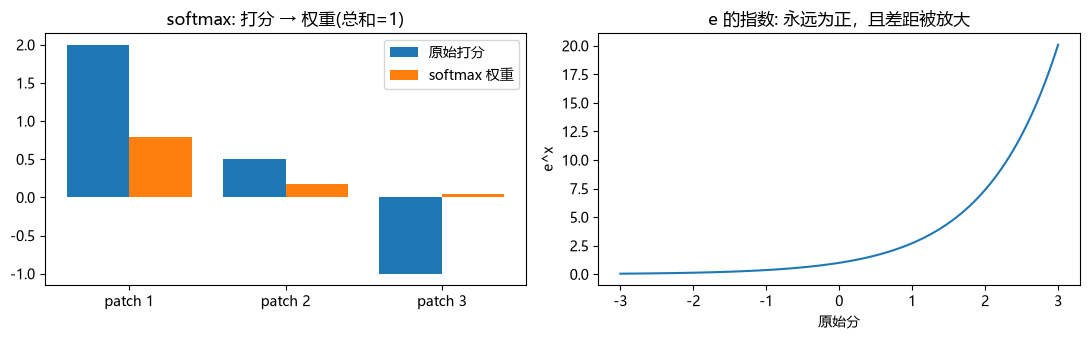

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 中文字体，不设会出方块
plt.rcParams['axes.unicode_minus'] = False

# ============ softmax 手算演示 ============
scores = np.array([2.0, 0.5, -1.0])          # 打分器给 3 个 patch 的原始打分
print('原始打分:', scores)
print('① 直接除以总和行不行? 总和 =', scores.sum(), ' → 负数、总和可能为0，行不通')
exp_scores = np.exp(scores)                   # ② 先取 e 的指数
print('② e 的指数: e^2.0=%.2f, e^0.5=%.2f, e^(-1)=%.2f' % tuple(exp_scores))
weights = exp_scores / exp_scores.sum()       # ③ 再除以总和
print('③ 除以总和 %.2f → 权重:' % exp_scores.sum(), np.round(weights, 3),
      ' (验证: 加起来 = %.2f)' % weights.sum())

# 对比：打分差距拉大后，权重会发生什么变化
confident = np.exp(scores * 5) / np.exp(scores * 5).sum()
print()
print('如果打分器"更有自信"(分数×5 = [10, 2.5, -5]):')
print('  权重变成:', np.round(confident, 4), ' → 第 1 个 patch 几乎拿走全部预算')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
x = np.arange(3)
axes[0].bar(x - 0.2, scores, width=0.4, label='原始打分')
axes[0].bar(x + 0.2, weights, width=0.4, label='softmax 权重')
axes[0].set_xticks(x, ['patch 1', 'patch 2', 'patch 3']); axes[0].legend()
axes[0].set_title('softmax: 打分 → 权重(总和=1)')
axes[1].plot(np.linspace(-3, 3, 100), np.exp(np.linspace(-3, 3, 100)))
axes[1].set_title('e 的指数: 永远为正，且差距被放大'); axes[1].set_xlabel('原始分'); axes[1].set_ylabel('e^x')
plt.tight_layout(); plt.show()

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # Windows 自带中文字体，不设的话图里中文会变方块
plt.rcParams['axes.unicode_minus'] = False             # 让负号正常显示

rng = np.random.default_rng(42)   # 固定随机种子：你跑出来的结果和我的一模一样

N_PER_CLASS = 100    # 正常 100 张 + 肿瘤 100 张
N_PATCHES   = 100    # 每张切片 100 个 patch
DIM         = 4      # 每个 patch 用 4 个数字表示
N_TUMOR     = 5      # 肿瘤切片里藏 5 个肿瘤 patch（只占 5%！）

def make_bag(has_tumor):
    """造一张假切片。返回 (patch特征矩阵, 每个patch是否为肿瘤的真值数组)。"""
    feats = rng.normal(0, 1, size=(N_PATCHES, DIM))          # 先铺满正常 patch
    truth = np.zeros(N_PATCHES, dtype=bool)                  # 真值：全 False
    if has_tumor:
        idx = rng.choice(N_PATCHES, N_TUMOR, replace=False)  # 随机选 5 个位置
        feats[idx] = rng.normal(2, 1, size=(N_TUMOR, DIM))   # 换成肿瘤 patch
        truth[idx] = True
    return feats.astype(np.float32), truth

# 造整个数据集：bags = 200 张切片，truths 留作"标准答案"（训练时绝不给模型看！）
bags, labels, truths = [], [], []
for i in range(N_PER_CLASS * 2):
    has_tumor = i >= N_PER_CLASS                    # 前 100 张正常，后 100 张肿瘤
    b, t = make_bag(has_tumor)
    bags.append(b); labels.append(int(has_tumor)); truths.append(t)

# 再造 200 张独立的"考试卷"：同样的造法，训练时完全不碰
test_bags, test_labels, test_truths = [], [], []
for i in range(N_PER_CLASS * 2):
    b, t = make_bag(i >= N_PER_CLASS)
    test_bags.append(b); test_labels.append(int(i >= N_PER_CLASS)); test_truths.append(t)

print(f'训练集: {len(bags)} 张切片 | 考试卷: {len(test_bags)} 张（不参与训练）')
print(f'每张 {bags[0].shape[0]} 个 patch, 每个 patch {bags[0].shape[1]} 维')
print(f'标签: {sum(labels)} 张肿瘤 / {len(labels)-sum(labels)} 张正常')
print(f'第 150 张切片里, 肿瘤 patch 的位置: {np.where(truths[150])[0]}')

训练集: 200 张切片 | 考试卷: 200 张（不参与训练）
每张 100 个 patch, 每个 patch 4 维
标签: 100 张肿瘤 / 100 张正常
第 150 张切片里, 肿瘤 patch 的位置: [19 33 34 81 91]


## 2. 先看看数据长什么样

取第 1、2 维画散点。注意看：肿瘤 patch（红）和正常 patch（灰）**有重叠**——单个 patch 根本没法 100% 区分，
这就是真实病理的常态（所以模型需要"综合多个可疑证据"，而不是指望某个 patch 一锤定音）。

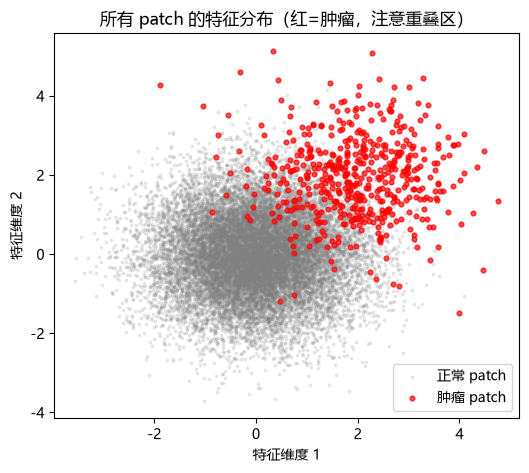

In [3]:
all_feats = np.vstack(bags)                       # 所有 patch 堆一起: (20000, 4)
all_truth = np.concatenate(truths)                # 对应的真值
plt.figure(figsize=(6, 5))
plt.scatter(all_feats[~all_truth, 0], all_feats[~all_truth, 1],
            s=3, alpha=0.15, c='gray', label='正常 patch')
plt.scatter(all_feats[all_truth, 0], all_feats[all_truth, 1],
            s=12, alpha=0.7, c='red', label='肿瘤 patch')
plt.xlabel('特征维度 1'); plt.ylabel('特征维度 2')
plt.legend(); plt.title('所有 patch 的特征分布（红=肿瘤，注意重叠区）')
plt.show()

## 3. 笨办法：取平均（mean pooling）

最直觉的做法：把一张切片的 100 个 patch **求平均**得到一个 4 维向量，再训练一个线性分类器。

🤔 先想一下会有什么问题：肿瘤信号只存在于 5 个 patch 里，平均之后被稀释了 **20 倍**。
就像把一滴墨水滴进一杯水——颜色还在，但很淡了。

In [4]:
def train_and_eval(model_fn, epochs=300, lr=0.05, quiet=False):
    """通用训练循环：model_fn() 返回一个模型，输入 (100,4) 输出 (logit, 注意力或None)。"""
    model = model_fn()
    opt = torch.optim.Adam(model.parameters(), lr=lr)   # Adam = 最常用的优化器
    loss_fn = nn.BCEWithLogitsLoss()                    # 二分类标准损失
    y_all = torch.tensor(labels, dtype=torch.float32)
    history = []
    for ep in range(epochs):
        total, correct = 0.0, 0
        for i, bag in enumerate(bags):
            H = torch.from_numpy(bag)                   # numpy → torch
            logit, _ = model(H)                         # 前向：出 1 个分数
            loss = loss_fn(logit, y_all[i][None])       # 和标签算损失
            opt.zero_grad(); loss.backward(); opt.step()# 反向传播 + 更新参数
            total += loss.item()
            correct += int((logit.item() > 0) == bool(labels[i]))
        history.append((total / len(bags), correct / len(bags)))
        if not quiet and ep % 100 == 99:
            print(f'epoch {ep+1:3d}: loss={history[-1][0]:.4f}  训练准确率={history[-1][1]:.1%}')
    if not quiet:
        print(f'考试卷（没参与训练的 200 张）准确率 = {test_accuracy(model):.1%}')
    return model, history

def test_accuracy(model):
    """在独立考试卷上的准确率——训练准确率会高估，考试卷才是真本事。"""
    with torch.no_grad():
        pred = [model(torch.from_numpy(b))[0].item() > 0 for b in test_bags]
    return float(np.mean([p == bool(y) for p, y in zip(pred, test_labels)]))

class MeanPool(nn.Module):
    """笨办法：100 个 patch 取平均 → 线性分类器。"""
    def __init__(self, dim=4):
        super().__init__()
        self.clf = nn.Linear(dim, 1)
    def forward(self, H):
        return self.clf(H.mean(dim=0)), None            # H.mean: 所有 patch 一视同仁

print('=== 笨办法（取平均）===')
model_mean, hist_mean = train_and_eval(lambda: MeanPool(DIM))

=== 笨办法（取平均）===


epoch 100: loss=0.4530  训练准确率=77.0%


epoch 200: loss=0.4530  训练准确率=77.0%


epoch 300: loss=0.4530  训练准确率=77.0%
考试卷（没参与训练的 200 张）准确率 = 84.0%


## 4. 注意力办法：让每个 patch 自己"举手"

改动只有一层窗户纸：不求平均，改成**加权平均**，权重由一个小打分器学出来——

```
每个 patch → 打分器 → 原始分 → softmax(归一化成总和=1) → 权重 A
切片表示 M = Σ Aᵢ · hᵢ        （重要 patch 话语权大）
预测 ŷ = 分类器(M)
```

（softmax 和加权平均的细节在 **1.5 节**用手算讲过，忘了就回去看一眼。）

整个模型只有 10 个参数（打分器 4+1，分类器 4+1）。训练时梯度会自动惩罚"把注意力分给无关 patch"的行为——
因为那样 M 里的肿瘤信号就弱，分类就错。

### 4.5 先拿 5 个 patch 手算一遍完整流程（强烈建议逐行看）

不看框架，先用具体数字把"打分 → softmax → 加权平均 → 分类"这条链走一遍。
注意第三步的产物：**整张切片的表示 M 会长得很像肿瘤 patch**——因为权重集中在它们身上。这就是"证据被放大、噪声被稀释"。

In [5]:
import torch

# 一张只有 5 个 patch 的迷你切片（每个 patch 4 维，肉眼可读的数）
H5 = torch.tensor([[ 0.1,  0.2, -0.1,  0.0],     # patch 0: 正常
                   [ 0.0, -0.2,  0.1,  0.1],     # patch 1: 正常
                   [ 2.1,  1.8,  2.2,  1.9],     # patch 2: 肿瘤（数值明显偏大）
                   [-0.1,  0.0,  0.2, -0.1],     # patch 3: 正常
                   [ 1.9,  2.0,  1.8,  2.1]])    # patch 4: 肿瘤

# 打分器 = 4 个权重 + 1 个偏置，共 5 个旋钮。假设已经训练好了（肿瘤 patch 得分高）
w = torch.tensor([0.8, 0.8, 0.8, 0.8])   # 每个维度都"往大看"（因为肿瘤 patch 数值偏大）
b = torch.tensor(0.0)

print('① 打分：每个 patch 的 4 个数 × 权重后相加 (score = w·h + b)')
s = H5 @ w + b                            # @ 就是"逐维相乘再相加"
for i, v in enumerate(s):
    tag = ' ← 肿瘤' if i in (2, 4) else ''
    print(f'   patch {i}: score = {v.item():+.2f}{tag}')

print()
print('② softmax：打分 → 权重（总和=1 的预算）')
A5 = torch.softmax(s, dim=0)
for i, v in enumerate(A5):
    print(f'   patch {i}: 注意力权重 = {v.item():.4f}   {"█" * int(v.item() * 50)}')
print(f'   权重总和 = {A5.sum().item():.2f}')

print()
print('③ 加权平均：5 个 patch 按权重"投票"，合成整张切片的表示')
M5 = (A5.unsqueeze(1) * H5).sum(dim=0)
print('   切片表示 M =', np.round(M5.numpy(), 3),
      '  ← 注意它非常接近肿瘤 patch 的样子（因为权重集中在 patch 2 和 4）')

print()
print('④ 分类：分类器看 M 做最终判断（这里也是 5 个旋钮）')
print('   M 里的数值越大越像肿瘤 → logit > 0 → 预测"肿瘤" ✓')
print()
print('训练就是：一开始 w 是随机的（乱打分）→ 分类猜错 → 自动把 w 往"让肿瘤 patch 得分更高"的方向拧一点点 → 重复几百次。')
print('全程没人告诉它"patch 2 和 4 是肿瘤"——这是从"切片=肿瘤"这个粗标签里反推出来的。')

① 打分：每个 patch 的 4 个数 × 权重后相加 (score = w·h + b)
   patch 0: score = +0.16
   patch 1: score = +0.00
   patch 2: score = +6.40 ← 肿瘤
   patch 3: score = +0.00
   patch 4: score = +6.24 ← 肿瘤

② softmax：打分 → 权重（总和=1 的预算）
   patch 0: 注意力权重 = 0.0010   
   patch 1: 注意力权重 = 0.0009   
   patch 2: 注意力权重 = 0.5384   ██████████████████████████
   patch 3: 注意力权重 = 0.0009   
   patch 4: 注意力权重 = 0.4588   ██████████████████████
   权重总和 = 1.00

③ 加权平均：5 个 patch 按权重"投票"，合成整张切片的表示
   切片表示 M = [2.002 1.887 2.01  1.986]   ← 注意它非常接近肿瘤 patch 的样子（因为权重集中在 patch 2 和 4）

④ 分类：分类器看 M 做最终判断（这里也是 5 个旋钮）
   M 里的数值越大越像肿瘤 → logit > 0 → 预测"肿瘤" ✓

训练就是：一开始 w 是随机的（乱打分）→ 分类猜错 → 自动把 w 往"让肿瘤 patch 得分更高"的方向拧一点点 → 重复几百次。
全程没人告诉它"patch 2 和 4 是肿瘤"——这是从"切片=肿瘤"这个粗标签里反推出来的。


## 4.6 手算时间：一张 3-patch 迷你切片，把 §3、§4 和"训练一步"全算给你看

纸上得来终觉浅。造一张小到能手算的切片——3 个 patch、每个只有 2 个数：

```
patch 1 = [0.1, 0.0]   （正常）        patch 2 = [0.0, 0.2]   （正常）
patch 3 = [2.0, 1.8]   （肿瘤——数值明显大）
切片标签 y = 1（肿瘤）    分类器（两节共用）：logit = M₁ + M₂ − 1，再 sigmoid
```

### §3 取平均，逐步算

**① 求平均**：`M = ⅓[0.1,0] + ⅓[0,0.2] + ⅓[2,1.8] = [0.70, 0.67]`
⚠️ 肿瘤 patch 的数值是 2.0 量级，平均后只剩 0.7——**稀释了 3 倍**（玩具版正文是 20 倍，真实切片可能是 100 倍）。
**② 分类**：`logit = 0.70 + 0.67 − 1 = 0.37 → p = σ(0.37) = 0.59`，信心微弱。
**③ 训练救不了它**：M 是"平均"这个死操作决定的，模型改不了；只能硬放大分类器权重去凑，泛化必差。

### §4 注意力，逐步算（假设打分器已练好：score = 0.8·h₁ + 0.8·h₂）

**① 打分**：`s = [0.8·0.1+0.8·0,  0.8·0+0.8·0.2,  0.8·2+0.8·1.8] = [0.08, 0.16, 3.04]`
**② softmax**：`e^s = [1.08, 1.17, 20.91]`，总和 23.16 → `A = [0.047, 0.051, 0.903]` —— 肿瘤独占 90% 预算。
**③ 加权平均**：`M = 0.047·[0.1,0] + 0.051·[0,0.2] + 0.903·[2,1.8] = [1.81, 1.63]` —— 信号几乎没稀释（1.81 vs 原来的 2.0）。
**④ 分类**：`logit = 1.81 + 1.63 − 1 = 2.44 → p = σ(2.44) = 0.92` ✓ 果断判对（vs 取平均的 0.59）。

### 关键一步：打分器是怎么学出来的？（手算一步梯度下降）

初始打分器是随机的，比如 `w = [0, 0]`。那么所有 patch 同分，`softmax([0,0,0]) = [⅓, ⅓, ⅓]`——**注意：没训练的注意力 = 取平均！**（此刻 p = 0.59，和 §3 一模一样。）

错误量 = p − y = 0.59 − 1 = **−0.41**（猜低了）。梯度对分数的调整规则，说人话就一句：

> **某 patch 的"个人意见"（分类器单独看它时的打分）如果比当前加权平均意见更正确，就抬高它的分数；否则压低。**

三个 patch 的个人意见分别是 0.1、0.2、3.8，当前加权平均意见 = 1.37。只有 patch 3 远超平均 → 只有它被抬高。调整一步之后：`A = [0.087, 0.091, 0.822]`，p 从 0.59 跳到 0.90；更新 5 次后 `A = [0.037, 0.040, 0.923]`，第 6 次更新后打分器停在 `w ≈ [0.96, 0.84]`。

**全程没有任何人告诉它 patch 3 是肿瘤**——唯一线索是"整张切片是肿瘤，你得想办法猜对"。这就是弱监督的全部魔法。下面代码逐行打印，和手算对照：

In [6]:
# ============ 手算一步梯度下降（每一步都让 Python 打印出来对照） ============
H3 = np.array([[0.1, 0.0],      # patch 1: 正常
               [0.0, 0.2],      # patch 2: 正常
               [2.0, 1.8]])     # patch 3: 肿瘤
y = 1.0
sigmoid = lambda x: 1 / (1 + np.exp(-x))
w_clf, b_clf = np.array([1.0, 1.0]), -1.0     # 分类器（固定不动，只看打分器怎么学）

print('【§3 取平均】')
M = H3.mean(0)
p_mean = sigmoid(w_clf @ M + b_clf)
print(f'  M = {np.round(M, 4)}  → logit = {w_clf @ M + b_clf:.4f} → p = {p_mean:.4f}（信心微弱）')

print()
print('【§4 注意力（打分器已练好 w=[0.8, 0.8]）】')
s = H3 @ np.array([0.8, 0.8])
A = np.exp(s) / np.exp(s).sum()
M = A @ H3
print(f'  打分 s = {np.round(s, 4)}')
print(f'  e 的指数 = {np.round(np.exp(s), 4)}，总和 = {np.exp(s).sum():.3f}')
print(f'  注意力 A = {np.round(A, 4)}  ← patch 3 独占 {A[2]:.1%} 预算')
print(f'  M = {np.round(M, 4)}（肿瘤信号保住了：1.81 vs 原来的 2.0）')
print(f'  p = {sigmoid(w_clf @ M + b_clf):.4f}（vs 取平均的 {p_mean:.2f}）')

print()
print('【训练手算：打分器从 w=[0,0] 开始，走 6 步】')
print('  调整规则（人话版）：某 patch 的"个人意见"比加权平均意见更正确 → 抬高它的分数，否则压低')
w_att = np.array([0.0, 0.0])
for step in range(6):
    s = H3 @ w_att
    A = np.exp(s) / np.exp(s).sum()
    M = A @ H3
    p = sigmoid(w_clf @ M + b_clf)
    u = H3 @ w_clf                       # 分类器对每个 patch 的"个人意见"
    dL_ds = (p - y) * A * (u - A @ u)    # softmax 链式法则的成品公式
    w_att = w_att - 1.0 * (H3.T @ dL_ds) # 梯度下降一步（学习率 1）
    print(f'  step {step}: A={np.round(A, 3)}  p={p:.3f}  分数调整量={np.round(-dL_ds, 3)}')
print(f'  收敛后打分器 w = {np.round(w_att, 3)}（自己学会了"往大看"）')
print()
print('注意 step 0：A = [1/3, 1/3, 1/3] —— 没训练的注意力就是取平均。')
print('取平均不是"另一个模型"，而是注意力的"零训练起点"。')

【§3 取平均】
  M = [0.7    0.6667]  → logit = 0.3667 → p = 0.5907（信心微弱）

【§4 注意力（打分器已练好 w=[0.8, 0.8]）】
  打分 s = [0.08 0.16 3.04]
  e 的指数 = [ 1.0833  1.1735 20.9052]，总和 = 23.162
  注意力 A = [0.0468 0.0507 0.9026]  ← patch 3 独占 90.3% 预算
  M = [1.8098 1.6347]（肿瘤信号保住了：1.81 vs 原来的 2.0）
  p = 0.9202（vs 取平均的 0.59）

【训练手算：打分器从 w=[0,0] 开始，走 6 步】
  调整规则（人话版）：某 patch 的"个人意见"比加权平均意见更正确 → 抬高它的分数，否则压低
  step 0: A=[0.333 0.333 0.333]  p=0.591  分数调整量=[-0.173 -0.159  0.332]
  step 1: A=[0.087 0.091 0.822]  p=0.896  分数调整量=[-0.028 -0.028  0.056]
  step 2: A=[0.063 0.067 0.87 ]  p=0.911  分数调整量=[-0.018 -0.019  0.037]
  step 3: A=[0.051 0.054 0.895]  p=0.918  分数调整量=[-0.014 -0.014  0.028]
  step 4: A=[0.043 0.046 0.912]  p=0.923  分数调整量=[-0.011 -0.012  0.023]
  step 5: A=[0.037 0.04  0.923]  p=0.926  分数调整量=[-0.009 -0.01   0.019]
  收敛后打分器 w = [0.963 0.842]（自己学会了"往大看"）

注意 step 0：A = [1/3, 1/3, 1/3] —— 没训练的注意力就是取平均。
取平均不是"另一个模型"，而是注意力的"零训练起点"。


=== 注意力办法 ===


epoch 100: loss=0.0537  训练准确率=98.5%


epoch 200: loss=0.0530  训练准确率=98.5%


epoch 300: loss=0.0551  训练准确率=99.0%
考试卷（没参与训练的 200 张）准确率 = 95.5%


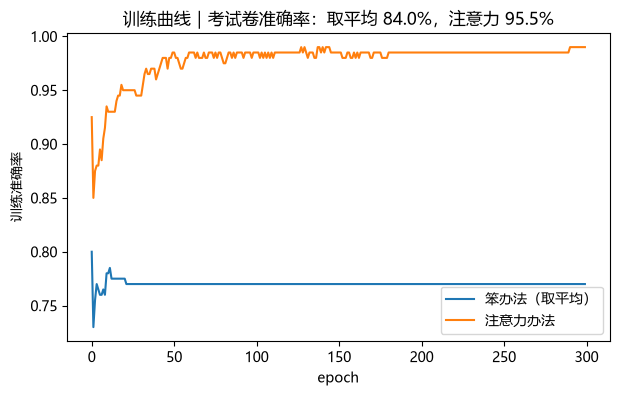

In [7]:
class AttnMIL(nn.Module):
    """注意力办法：这就是 CLAM 的最小骨架（它只是在每一环上加深加大）。"""
    def __init__(self, dim=4):
        super().__init__()
        self.attn = nn.Linear(dim, 1)   # 打分器：4 维 → 1 个分数
        self.clf  = nn.Linear(dim, 1)   # 分类器：加权表示 → logit
    def forward(self, H):
        A = torch.softmax(self.attn(H), dim=0)  # (100,1)，所有 patch 权重和 = 1
        M = (A * H).sum(dim=0)                  # 加权平均 → (4,)
        return self.clf(M), A

print('=== 注意力办法 ===')
model_attn, hist_attn = train_and_eval(lambda: AttnMIL(DIM))

# 两条训练准确率曲线画一起，标题里写上考试卷成绩
plt.figure(figsize=(7, 4))
plt.plot([h[1] for h in hist_mean], label='笨办法（取平均）')
plt.plot([h[1] for h in hist_attn], label='注意力办法')
plt.xlabel('epoch'); plt.ylabel('训练准确率'); plt.legend()
plt.title(f'训练曲线｜考试卷准确率：取平均 {test_accuracy(model_mean):.1%}，注意力 {test_accuracy(model_attn):.1%}')
plt.show()

## 5. 见证时刻：它真的找到肿瘤 patch 了吗？

准确率只是副产品，真正的魔术是：**注意力分数（模型自己学的）和我们藏起来的标准答案对得上吗？**
从**考试卷**里取一张肿瘤切片（模型训练时没见过它），把每个 patch 的注意力分数画出来，红色 = 真实的肿瘤 patch。
然后把考试卷里全部 100 张肿瘤切片都查一遍，算平均命中率——只看一张容易挑到好看的例子。

注意力 Top-5 的 patch: [19, 29, 53, 62, 71]
真实肿瘤 patch 位置:   [19, 29, 53, 62, 71]
命中: 5/5   ← 没人教过它，它自己学会的
考试卷 100 张肿瘤切片: Top-5 注意力里真肿瘤的平均比例 = 87.4%（随机挑 = 5%）


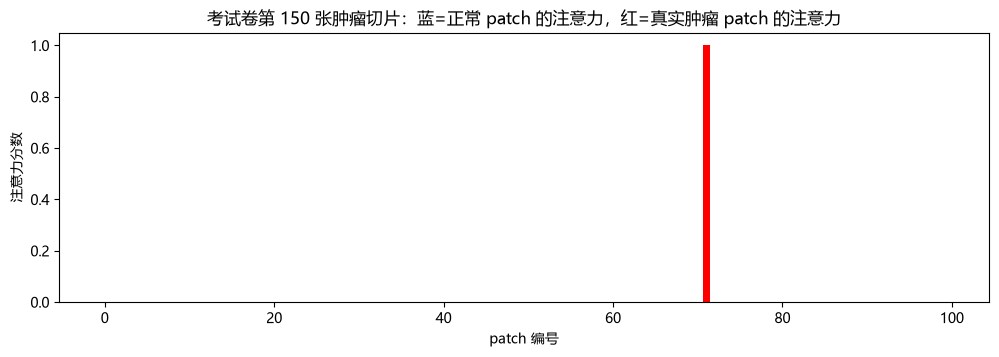

In [8]:
demo_idx = 150                                    # 考试卷里的第 150 张（肿瘤切片）
with torch.no_grad():
    _, A = model_attn(torch.from_numpy(test_bags[demo_idx]))
A = A.squeeze().numpy()
truth = test_truths[demo_idx]

top5 = A.argsort()[-5:]                           # 注意力最高的 5 个 patch
hit = int(sum(truth[top5]))                       # 其中几个是真肿瘤？
print(f'注意力 Top-5 的 patch: {sorted(int(i) for i in top5)}')
print(f'真实肿瘤 patch 位置:   {sorted(int(i) for i in np.where(truth)[0])}')
print(f'命中: {hit}/5   ← 没人教过它，它自己学会的')

# 全部 100 张考试卷肿瘤切片的平均命中率（随机挑 5 个 patch 的期望命中率 = 5%）
hits = []
with torch.no_grad():
    for b, t, y in zip(test_bags, test_truths, test_labels):
        if y == 1:
            a = model_attn(torch.from_numpy(b))[1].squeeze().numpy()
            hits.append(t[a.argsort()[-5:]].mean())
print(f'考试卷 100 张肿瘤切片: Top-5 注意力里真肿瘤的平均比例 = {np.mean(hits):.1%}（随机挑 = 5%）')

plt.figure(figsize=(12, 3.5))
plt.bar(range(N_PATCHES), A, color=['red' if t else 'steelblue' for t in truth])
plt.xlabel('patch 编号'); plt.ylabel('注意力分数')
plt.title(f'考试卷第 {demo_idx} 张肿瘤切片：蓝=正常 patch 的注意力，红=真实肿瘤 patch 的注意力')
plt.show()

## 6. 加码实验：肿瘤占比越来越小时呢？

真实病理里，肿瘤可能只占整张切片的 **1% 都不到**。把肿瘤 patch 占比从 10% 一路降到 1%，看两种方法什么时候崩。
每个占比都重造训练集和考试卷，比的是**考试卷准确率**。
这就是 CLAM 这类方法存在的根本原因——**不是锦上添花，是雪中送炭**。

肿瘤占比 10%:  考试卷准确率  取平均=96.0%   注意力=99.0%


肿瘤占比  5%:  考试卷准确率  取平均=78.0%   注意力=97.0%


肿瘤占比  3%:  考试卷准确率  取平均=54.0%   注意力=92.5%


肿瘤占比  1%:  考试卷准确率  取平均=50.0%   注意力=50.0%


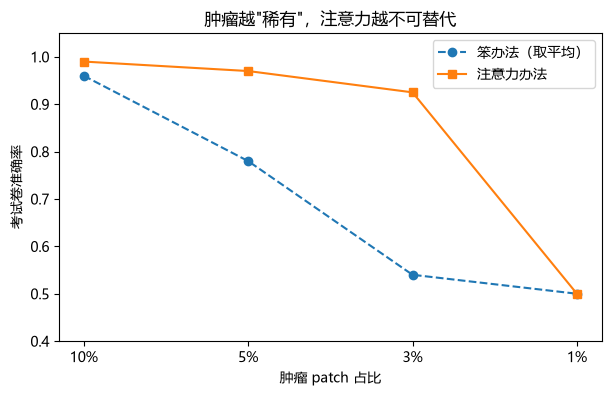

In [9]:
def rebuild_dataset(n_tumor):
    """按新的肿瘤 patch 数重造训练集和考试卷（训练集种子 42，考试卷种子 1042）。"""
    global bags, labels, truths, test_bags, test_labels, test_truths
    def make(seed):
        r = np.random.default_rng(seed)
        B, Ls, Ts = [], [], []
        for i in range(N_PER_CLASS * 2):
            has_tumor = i >= N_PER_CLASS
            feats = r.normal(0, 1, size=(N_PATCHES, DIM)).astype(np.float32)
            truth = np.zeros(N_PATCHES, dtype=bool)
            if has_tumor:
                idx = r.choice(N_PATCHES, n_tumor, replace=False)
                feats[idx] = r.normal(2, 1, size=(n_tumor, DIM))
                truth[idx] = True
            B.append(feats); Ls.append(int(has_tumor)); Ts.append(truth)
        return B, Ls, Ts
    bags, labels, truths = make(42)
    test_bags, test_labels, test_truths = make(1042)

fracs, acc_mean, acc_attn = [], [], []
for nt in [10, 5, 3, 1]:                          # 肿瘤 patch 数：10% → 1%
    rebuild_dataset(nt)
    m_mean, _ = train_and_eval(lambda: MeanPool(DIM), quiet=True)
    m_attn, _ = train_and_eval(lambda: AttnMIL(DIM), quiet=True)
    fracs.append(f'{nt}%'); acc_mean.append(test_accuracy(m_mean)); acc_attn.append(test_accuracy(m_attn))
    print(f'肿瘤占比 {nt:2d}%:  考试卷准确率  取平均={acc_mean[-1]:.1%}   注意力={acc_attn[-1]:.1%}')

plt.figure(figsize=(7, 4))
plt.plot(fracs, acc_mean, 'o--', label='笨办法（取平均）')
plt.plot(fracs, acc_attn, 's-', label='注意力办法')
plt.xlabel('肿瘤 patch 占比'); plt.ylabel('考试卷准确率'); plt.ylim(0.4, 1.05)
plt.legend(); plt.title('肿瘤越"稀有"，注意力越不可替代')
plt.show()

rebuild_dataset(N_TUMOR)   # 恢复 5% 数据集，供后面的 cell 用

**读结果**：
- 10% 时两种方法都不错；降到 5%、3% 时，取平均在考试卷上掉到 78%、54%，注意力还有 97%、92.5%——证据越稀有，"按重要性加权"越关键。
- 1% 时（每张切片只有 **1 个**肿瘤 patch），两种方法在考试卷上都接近瞎猜。这一版之前只看训练准确率，1% 时注意力有 86.5%——那是把 200 张训练切片"背"下来了，不是学会了。
- 教训有两条：① 成绩一定要在没参与训练的数据上算；② 证据越稀有，需要的训练切片越多——这也是真实 CLAM 要用几百上千张切片的原因之一。

## 7. 对照表：玩具版 ↔ 真实 CLAM_SB

现在回看主 notebook §5 打印出来的 CLAM_SB 结构，每一层都只是给玩具版"加料"：

| 玩具版（本 notebook） | CLAM_SB（真实模型） | 加料的目的 |
|---|---|---|
| patch 是 4 维向量 | patch 是 1024 维（ImageNet 预训练的 ResNet50 截到 layer3） | 真实图片信息量大 |
| 直接打分 | 先 `fc1: Linear(1024→512)+ReLU+Dropout` 变换再打分 | 把通用特征转成任务相关的表示 |
| `nn.Linear(4,1)` 一个打分器 | **门控**打分器：tanh 路 × sigmoid 路（512→256），再 256→1 | gated attention（Ilse et al. 2018）：单用 tanh 在 0 附近近似线性，乘上 sigmoid "门"后打分器能表达更复杂的模式 |
| softmax 加权平均 | 一模一样（softmax 加权平均） | — |
| `nn.Linear(4,1)` 分类器 | `nn.Linear(512, 2)` 分类器 | — |
| 只有包级损失 | **+ 实例级支线**：真实类别分支里注意力最高的 8 个 patch 当"正例"、最低的 8 个当"负例"，训练一个 patch 级小分类器（SmoothTop1SVM 损失）；亚型任务里其他类别分支的高分 patch 也当负例 | 用注意力自己产生的伪标签给 patch 级监督，让高、低注意力 patch 在特征空间里可分 |
| 总参数 10 个 | 总参数 790,791 个 | 依然袖珍（对比：完整 ResNet50 约 2500 万） |

**所以 CLAM = 玩具版 ×（更深的打分器 + 门控 + 实例级伪标签约束）。骨架没变。**

## 8. 三句话小结

1. **弱监督的核心矛盾**：标签在切片级，证据在 patch 级，而且证据可能只占 1%。
2. **注意力 = 可学习的加权平均**：打分器给出原始分，softmax 把分变成"总和=1 的注意力预算"；梯度下降会自动把预算推向"对分类有用的 patch"——找证据和下诊断是同一个优化过程。
3. **热图是免费的副产品，但要会读**：训练完把每个 patch 的注意力分数按坐标画回原切片，就是"对模型判断贡献最大的区域图"。玩具里肿瘤 patch 是唯一的区分信号，所以注意力正好落在肿瘤上；真实切片里，高注意力也可能落在与标签相关的"捷径"上（不同医院的染色色调、出血、炭末、褶皱等），而且 CLAM_SB 只有一个注意力分支，两类的证据都会拿高分——热图需要病理医生核对，不能直接当肿瘤标注用。

→ 回主 notebook [CLAM_workflow.ipynb](CLAM_workflow.ipynb) §5（训练）和 §7（热图），看真实模型怎么跑。
→ 继续读玩具版姊妹篇：[UNI2](UNI2_原理_玩具版.ipynb)（特征提取器怎么无标签训练）/ [CONCH](CONCH_原理_玩具版.ipynb)（模型怎么学会"看懂文字"）/ [TITAN](TITAN_原理_玩具版.ipynb)（整张切片的基础模型）。